# 期現套利 HBT：每日持久化跨日 Runner

## Goal

這個 Notebook 是位於 root `notebooks/` 的新版 full-market pipeline 薄 runner。它透過 `future_spot` strategy adapter 使用 neutral `hftbacktest_slim` API，預設由 Slim Rust engine 直接讀取 Arrow compact BBO cache；Reference HftBacktest 保留為回歸 oracle 與不支援模式的 fallback。日期依序處理、同日 pairs 使用同一個常駐 worker pool，未平倉部位以原期貨合約帶入下一日。

`report_mode='summary'` 會在每個日期完成後，把 summary、trades、market、latency、entry/exit、carry 與 errors 原子發布到 `output/core/dates/trade_date=YYYY-MM-DD/`。年度大型明細不留在記憶體；重新執行時只重用 manifest、資料 identity 與 carry chain 全部驗證成功的連續日期。

In [3]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

REPOSITORY_ROOT = Path.cwd().resolve().parent
print(f'REPOSITORY_ROOT: {REPOSITORY_ROOT}')
if not (REPOSITORY_ROOT / 'future_spot').is_dir():
    raise FileNotFoundError('Start Jupyter from the repository root before opening this notebook')
FUTURE_SPOT_ROOT = REPOSITORY_ROOT / 'future_spot'

from hftbacktest_slim import (
    COMPACT_BUILDER_VERSION,
    COMPACT_SCHEMA_VERSION,
    SLIM_ENGINE_VERSION,
    __version__ as SLIM_PACKAGE_VERSION,
)
from future_spot.test.backtest_config import default_notebook_args
from future_spot.test.backtest_pipeline import run_backtest_pipeline
from future_spot.test.report_tables import build_report_tables
from future_spot.test.report_plots import save_report_plots
from scripts.daily_result_store import DAILY_RESULT_SCHEMA_VERSION, DailyResultStore
from scripts.io_utils import read_csv_if_exists

REPOSITORY_ROOT: /home/zoufuc/hftbacktest


ModuleNotFoundError: No module named 'future_spot'

## Setup

### 1. 設定日期、延遲、資金與輸出模式

請先在 repository root 執行 `python3 -m pip install -e ./hftbacktest_slim`，再從同一個 root 啟動 Jupyter。Notebook 不修改 Python import search path，會直接使用 kernel environment 中已安裝的 neutral package。

第一次執行會逐日建立結果分區；同一組結果定義再次執行時會驗證並續跑。若程式、資料或參數 identity 改變，請使用新的 `output_dir`，不要覆蓋舊研究結果。

In [ ]:
# 這 8 個到期殘倉 run 會從 HBT、交易、績效與資金重播中刪除。
EXCLUDED_RUN_KEYS = {
    '2026-04-15::1802_KUFD6',
    '2026-05-20::6173_PKFE6',
    '2026-07-15::2340_FYFG6',
    '2026-07-15::2408_CYFG6',
    '2026-07-15::3714_QBFG6',
    '2026-07-15::4919_REFG6',
    '2026-07-15::5371_NMFG6',
    '2026-07-15::6257_MQFG6',
    '2026-07-15::3037_IRFG6'
}

args = default_notebook_args(
    start_date='2026-01-01',
    end_date='2026-01-15',
    output_dir=FUTURE_SPOT_ROOT / 'output' / 'hbt_daily_full_market_20260101_20260731_slim_compact_acc',
    engine='slim',
    market_data_cache='compact',
    compact_cache_root=FUTURE_SPOT_ROOT / 'output' / 'compact_bbo_v1',
    compact_cache_compression='lz4',
    carry_positions=True,
    total_capital=50_000_000.0,
    futures_margin_rate=0.20,
    spot_equity_rate=0.40,
    leverage=False,             # False：期貨與現股皆按 100% 自有資金
    future_order_latency_ms=1.0,
    future_response_latency_ms=1.0,
    future_feed_latency_offset_ms=0.0,
    spot_order_latency_ms=1.0,
    spot_response_latency_ms=35.0,
    spot_feed_latency_offset_ms=0.0,
    low_memory_reports=True,
    report_mode='summary',      # 啟用每日 Parquet、bounded memory 與 verified resume
    report_chunk_rows=25_000,
    continue_on_error=True,
    post_first_feed_wait='spot',
    post_first_feed_timeout_ms=5000.0,
    rebuild_hbt_results=False,
    excluded_run_keys=sorted(EXCLUDED_RUN_KEYS),
)

PLOT_EXCLUDED_DATES = tuple(args.excluded_dates)
print(f'Output: {args.output_dir}')
print(f'Engine/cache: {args.engine} / {args.market_data_cache}')
print(f'Compact cache: {args.compact_cache_root}')
print(f'Slim package/engine: {SLIM_PACKAGE_VERSION} / {SLIM_ENGINE_VERSION}')
print(f'Compact schema/builder: {COMPACT_SCHEMA_VERSION} / {COMPACT_BUILDER_VERSION}')
print(f'Daily result schema: {DAILY_RESULT_SCHEMA_VERSION}')

Output: /home/zoufuc/hftbacktest/future_spot/output/hbt_daily_full_market_20260101_20260731_slim_compact_acc
Engine/cache: slim / compact
Compact cache: /home/zoufuc/hftbacktest/future_spot/output/compact_bbo_v1
Daily result schema: 1


## Steps

### 2. 執行或續跑，顯示各階段耗時，並驗證每日 manifest、carry 與錯誤稽核

完整 timing audit 會保存為 `stage_timings.csv`。Notebook 顯示 pipeline 階段、各 stage 統計，以及逐交易日耗時；`date_total` 包含該日所有子階段，不應再與子階段相加。

In [ ]:
artifacts = run_backtest_pipeline(args)

stage_timings = artifacts.frame('stage_timings').copy()
stage_timings['elapsed_seconds'] = pd.to_numeric(stage_timings['elapsed_seconds'], errors='coerce')
pipeline_timings = stage_timings.loc[stage_timings['mode'].eq('pipeline')].copy()
timing_summary = (
    stage_timings.loc[stage_timings['stage'].ne('date_total')]
    .groupby(['mode', 'stage'], dropna=False)['elapsed_seconds']
    .agg(calls='size', total_seconds='sum', mean_seconds='mean', max_seconds='max')
    .reset_index()
    .sort_values('total_seconds', ascending=False)
)
daily_timings = (
    stage_timings.loc[stage_timings['trade_date'].notna()]
    .pivot_table(index=['trade_date', 'mode'], columns='stage', values='elapsed_seconds', aggfunc='sum')
    .reset_index()
)

print(f'Stage timing CSV: {artifacts.output_dir / "stage_timings.csv"}')
display(pipeline_timings[['stage', 'elapsed_seconds', 'pair_count']])
display(timing_summary)
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(daily_timings)
conversion_audit = artifacts.frame('conversion_status')
cache_audit_columns = [column for column in (
    'trade_date', 'compact_cache_state', 'compact_build_invocation_scan_count',
) if column in conversion_audit.columns]
if cache_audit_columns:
    display(conversion_audit[cache_audit_columns].drop_duplicates().sort_values('trade_date'))
result_store = DailyResultStore(artifacts.output_dir / 'core')

manifest_rows = []
for trade_date in artifacts.trade_dates:
    manifest = result_store.validate(trade_date)
    payload = manifest.payload
    manifest_rows.append({
        'trade_date': trade_date,
        'schema_version': payload['schema_version'],
        'engine': payload.get('metadata', {}).get('engine'),
        'time_in_force_semantics': payload.get('metadata', {}).get('time_in_force_semantics'),
        'run_keys': len(payload.get('run_keys', [])),
        'summary_rows': payload.get('tables', {}).get('summary', {}).get('rows', 0),
        'trade_rows': payload.get('tables', {}).get('trades', {}).get('rows', 0),
        'error_rows': payload.get('tables', {}).get('run_errors', {}).get('rows', 0),
        'manifest': str(manifest.path),
    })
daily_manifest_audit = pd.DataFrame(manifest_rows)
if len(daily_manifest_audit) != len(artifacts.trade_dates):
    raise RuntimeError('每日結果不是完整且連續的已驗證日期序列')

display(daily_manifest_audit.head(20))
display(artifacts.frame('summary').head(20))
entry_exit_index = read_csv_if_exists(artifacts.output_dir / 'entry_exit_index.csv')
display(entry_exit_index.head(20))

carry_status = artifacts.frame('position_carry_status')
if not carry_status.empty:
    display(carry_status.loc[carry_status['universe_source'].ne('selected')].head(30))
    expiry_violations = carry_status.loc[carry_status['status'].eq('expiry_position_remaining')].copy()
    if not expiry_violations.empty:
        display(expiry_violations)
        raise RuntimeError(f'期貨到期日仍有殘倉：{len(expiry_violations)} 筆')

run_errors = read_csv_if_exists(artifacts.output_dir / 'run_errors.csv')
print(f'run_errors.csv rows: {len(run_errors):,}')
if not run_errors.empty:
    display(run_errors.head(100))

for frame_name in ('summary', 'position_carry_status'):
    frame = artifacts.frame(frame_name)
    leaked = frame.loc[frame['run_key'].astype(str).isin(EXCLUDED_RUN_KEYS)] if not frame.empty else frame
    if not leaked.empty:
        raise RuntimeError(f'{frame_name} 仍含已排除 run_key：{sorted(leaked.run_key.unique())}')
for trade_date in artifacts.trade_dates:
    trades_for_date = result_store.load_table(trade_date, 'trades')
    if not trades_for_date.empty:
        leaked = trades_for_date.loc[trades_for_date['run_key'].astype(str).isin(EXCLUDED_RUN_KEYS)]
        if not leaked.empty:
            raise RuntimeError(f'trades 仍含已排除 run_key：{sorted(leaked.run_key.unique())}')

print('每日 manifest、跨日 carry、排除 run_key 與錯誤稽核完成。')

Stage timing CSV: /home/zoufuc/hftbacktest/future_spot/output/hbt_daily_full_market_20260101_20260731_slim_compact_acc/stage_timings.csv


,stage,elapsed_seconds,pair_count
0,prepare_args,0.000303,0
1,select_trade_dates,0.012907,0
2,build_daily_pair_records,574.346433,4456
3,execute_or_resume_hbt,10676.691645,4596
929,persist_audit_frames,0.140941,4596
930,write_backtest_manifest,461.066285,4596
931,entry_exit_handoff,0.000310,4596
932,pipeline_total,11712.278496,4596


,mode,stage,calls,total_seconds,mean_seconds,max_seconds
9,pipeline,pipeline_total,1,11712.278496,11712.278496,11712.278496
7,pipeline,execute_or_resume_hbt,1,10676.691645,10676.691645,10676.691645
3,executed,event_data,132,9300.289718,70.456740,148.416814
5,pipeline,build_daily_pair_records,1,574.346433,574.346433,574.346433
13,resume_check,daily_identity_validation,132,480.802720,3.642445,7.176709
12,pipeline,write_backtest_manifest,1,461.066285,461.066285,461.066285
4,executed,pair_matching,132,351.222031,2.660773,5.927829
14,run,compatibility_csv_stream,1,233.666838,233.666838,233.666838
2,executed,event_audit,132,188.822371,1.430473,2.791456
0,executed,carry_and_entry_exit,132,93.237771,0.706347,9.686565


stage,trade_date,mode,carry_and_entry_exit,daily_identity_validation,daily_result_publish,date_total,event_audit,event_data,pair_matching
0,2026-01-02,executed,0.000504,NaN,0.011695,0.013060,0.000038,0.000103,0.000122
1,2026-01-02,resume_check,NaN,0.000573,NaN,NaN,NaN,NaN,NaN
2,2026-01-05,executed,0.000317,NaN,0.011466,0.012679,0.000034,0.000089,0.000139
3,2026-01-05,resume_check,NaN,0.000617,NaN,NaN,NaN,NaN,NaN
4,2026-01-06,executed,0.000290,NaN,0.013300,0.014345,0.000032,0.000085,0.000127
5,2026-01-06,resume_check,NaN,0.000493,NaN,NaN,NaN,NaN,NaN
6,2026-01-07,executed,0.000268,NaN,0.011679,0.012782,0.000030,0.000082,0.000127
7,2026-01-07,resume_check,NaN,0.000579,NaN,NaN,NaN,NaN,NaN
8,2026-01-08,executed,0.115382,NaN,0.097217,72.784331,1.360532,64.035014,2.851815
9,2026-01-08,resume_check,NaN,4.324301,NaN,NaN,NaN,NaN,NaN


,trade_date,compact_cache_state,compact_build_invocation_scan_count
0,2026-01-08,miss,2
37,2026-01-09,miss,2
69,2026-01-12,miss,2
95,2026-01-13,miss,2
131,2026-01-14,miss,2
...,...,...,...
4435,2026-07-24,miss,2
4470,2026-07-28,miss,2
4494,2026-07-29,miss,2
4520,2026-07-30,miss,2


,trade_date,schema_version,engine,time_in_force_semantics,run_keys,summary_rows,trade_rows,error_rows,manifest
0,2026-01-02,1,slim,strict-v1,0,0,0,0,/home/zoufuc/hftbacktest/future_spot/output/hb...
1,2026-01-05,1,slim,strict-v1,0,0,0,0,/home/zoufuc/hftbacktest/future_spot/output/hb...
2,2026-01-06,1,slim,strict-v1,0,0,0,0,/home/zoufuc/hftbacktest/future_spot/output/hb...
3,2026-01-07,1,slim,strict-v1,0,0,0,0,/home/zoufuc/hftbacktest/future_spot/output/hb...
4,2026-01-08,1,slim,strict-v1,37,37,282,0,/home/zoufuc/hftbacktest/future_spot/output/hb...
5,2026-01-09,1,slim,strict-v1,32,32,5013,0,/home/zoufuc/hftbacktest/future_spot/output/hb...
6,2026-01-12,1,slim,strict-v1,26,26,10069,0,/home/zoufuc/hftbacktest/future_spot/output/hb...
7,2026-01-13,1,slim,strict-v1,36,36,5947,0,/home/zoufuc/hftbacktest/future_spot/output/hb...
8,2026-01-14,1,slim,strict-v1,40,40,313,0,/home/zoufuc/hftbacktest/future_spot/output/hb...
9,2026-01-15,1,slim,strict-v1,32,32,3510,0,/home/zoufuc/hftbacktest/future_spot/output/hb...


,trade_date,run_key,pair_name,spot_symbol,future_symbol,rows,filled_pairs,second_leg_failures,flatten_count,realized_pnl,...,post_first_feed_poll_ns,spot_order_latency_ns,future_order_latency_ns,spot_response_latency_ns,future_response_latency_ns,spot_feed_latency_offset_ns,future_feed_latency_offset_ns,strategy_engine,scan_calls,python_decisions
0,2026-01-08,2026-01-08::1303_CAFA6,1303_CAFA6,1303,CAFA6,0,0,0,0,0.0,...,10000000,1000000,1000000,35000000,1000000,0,0,python,0,15898
1,2026-01-08,2026-01-08::2002_CBFA6,2002_CBFA6,2002,CBFA6,0,0,0,0,0.0,...,10000000,1000000,1000000,35000000,1000000,0,0,python,0,15893
2,2026-01-08,2026-01-08::1301_CFFA6,1301_CFFA6,1301,CFFA6,0,0,0,0,0.0,...,10000000,1000000,1000000,35000000,1000000,0,0,python,0,15891
3,2026-01-08,2026-01-08::2409_CHFA6,2409_CHFA6,2409,CHFA6,0,0,0,0,0.0,...,10000000,1000000,1000000,35000000,1000000,0,0,python,0,15899
4,2026-01-08,2026-01-08::1605_CSFA6,1605_CSFA6,1605,CSFA6,0,0,0,0,0.0,...,10000000,1000000,1000000,35000000,1000000,0,0,python,0,15899
5,2026-01-08,2026-01-08::2408_CYFA6,2408_CYFA6,2408,CYFA6,0,0,0,0,0.0,...,10000000,1000000,1000000,35000000,1000000,0,0,python,0,15899
6,2026-01-08,2026-01-08::2603_CZFA6,2603_CZFA6,2603,CZFA6,0,0,0,0,0.0,...,10000000,1000000,1000000,35000000,1000000,0,0,python,0,15887
7,2026-01-08,2026-01-08::2609_DAFA6,2609_DAFA6,2609,DAFA6,0,0,0,0,0.0,...,10000000,1000000,1000000,35000000,1000000,0,0,python,0,15887
8,2026-01-08,2026-01-08::1101_DFFA6,1101_DFFA6,1101,DFFA6,0,0,0,0,0.0,...,10000000,1000000,1000000,35000000,1000000,0,0,python,0,15881
9,2026-01-08,2026-01-08::1326_DGFA6,1326_DGFA6,1326,DGFA6,0,0,0,0,0.0,...,10000000,1000000,1000000,35000000,1000000,0,0,python,0,15887


,trade_date,run_key,pair_name,rows,entry_signal_rows,entry_execution_rows,exit_execution_rows
0,2026-01-08,2026-01-08::1303_CAFA6,1303_CAFA6,0,0,0,0
1,2026-01-08,2026-01-08::2002_CBFA6,2002_CBFA6,0,0,0,0
2,2026-01-08,2026-01-08::1301_CFFA6,1301_CFFA6,0,0,0,0
3,2026-01-08,2026-01-08::2409_CHFA6,2409_CHFA6,0,0,0,0
4,2026-01-08,2026-01-08::1605_CSFA6,1605_CSFA6,0,0,0,0
5,2026-01-08,2026-01-08::2408_CYFA6,2408_CYFA6,0,0,0,0
6,2026-01-08,2026-01-08::2603_CZFA6,2603_CZFA6,0,0,0,0
7,2026-01-08,2026-01-08::2609_DAFA6,2609_DAFA6,0,0,0,0
8,2026-01-08,2026-01-08::1101_DFFA6,1101_DFFA6,0,0,0,0
9,2026-01-08,2026-01-08::1326_DGFA6,1326_DGFA6,0,0,0,0


,trade_date,run_key,pair_name,spot_symbol,future_symbol,universe_source,carried_from_date,initial_quantity,initial_direction,final_quantity,final_direction,expiry_date,is_expiry_date,carry_to_next_date,status
68,2026-01-09,2026-01-09::6770_QZFA6,6770_QZFA6,6770,QZFA6,carried_position,2026-01-08,9,ENTER_LONG_SPOT_SHORT_FUTURE,10,ENTER_LONG_SPOT_SHORT_FUTURE,2026-01-21,False,True,carried_forward
94,2026-01-12,2026-01-12::6770_QZFA6,6770_QZFA6,6770,QZFA6,carried_position,2026-01-09,10,ENTER_LONG_SPOT_SHORT_FUTURE,10,ENTER_LONG_SPOT_SHORT_FUTURE,2026-01-21,False,True,carried_forward
116,2026-01-13,2026-01-13::6282_KFFA6,6282_KFFA6,6282,KFFA6,selected+carried,2026-01-12,8,ENTER_LONG_SPOT_SHORT_FUTURE,0,HOLD,2026-01-21,False,False,closed
130,2026-01-13,2026-01-13::6770_QZFA6,6770_QZFA6,6770,QZFA6,carried_position,2026-01-12,10,ENTER_LONG_SPOT_SHORT_FUTURE,10,ENTER_LONG_SPOT_SHORT_FUTURE,2026-01-21,False,True,carried_forward
170,2026-01-14,2026-01-14::6770_QZFA6,6770_QZFA6,6770,QZFA6,carried_position,2026-01-13,10,ENTER_LONG_SPOT_SHORT_FUTURE,10,ENTER_LONG_SPOT_SHORT_FUTURE,2026-01-21,False,True,carried_forward
202,2026-01-15,2026-01-15::6770_QZFA6,6770_QZFA6,6770,QZFA6,carried_position,2026-01-14,10,ENTER_LONG_SPOT_SHORT_FUTURE,10,ENTER_LONG_SPOT_SHORT_FUTURE,2026-01-21,False,True,carried_forward
237,2026-01-16,2026-01-16::6770_QZFA6,6770_QZFA6,6770,QZFA6,carried_position,2026-01-15,10,ENTER_LONG_SPOT_SHORT_FUTURE,10,ENTER_LONG_SPOT_SHORT_FUTURE,2026-01-21,False,True,carried_forward
238,2026-01-19,2026-01-19::1303_CAFA6,1303_CAFA6,1303,CAFA6,selected+carried,2026-01-16,10,ENTER_LONG_SPOT_SHORT_FUTURE,0,HOLD,2026-01-21,False,False,closed
273,2026-01-19,2026-01-19::6770_QZFA6,6770_QZFA6,6770,QZFA6,carried_position,2026-01-16,10,ENTER_LONG_SPOT_SHORT_FUTURE,10,ENTER_LONG_SPOT_SHORT_FUTURE,2026-01-21,False,True,carried_forward
298,2026-01-20,2026-01-20::1717_QOFA6,1717_QOFA6,1717,QOFA6,selected+carried,2026-01-19,4,ENTER_LONG_SPOT_SHORT_FUTURE,0,HOLD,2026-01-21,False,False,closed


run_errors.csv rows: 0
每日 manifest、跨日 carry、排除 run_key 與錯誤稽核完成。


## Results

### 3. 以 bounded CSV chunks 產生資金與績效報表

大型明細已在日期邊界釋放；報表從每日分區串流產生的 compatibility CSV 讀取，不會重跑 HBT。

In [ ]:
reports = build_report_tables(artifacts)
display(reports.frame('symbol_profit').head(30))
display(reports.frame('failure_overview'))
display(reports.frame('capital_constraint_summary'))
display(reports.frame('daily_capital_constraint').tail(20))
print(f'Report CSV directory: {reports.output_dir}')

,spot_symbol,trade_days,pair_names,estimated_profit,avg_daily_profit,filled_pairs,second_leg_failures,flatten_count,final_quantity_abs
0,2492,22,6,3.476665e+06,158030.224818,284,25,10,24.0
1,2454,14,4,9.857453e+05,70410.377857,106,1,1,50.0
2,6488,10,3,9.791449e+05,97914.492200,334,41,26,69.0
3,2327,99,8,8.284682e+05,8368.365202,490,436,434,187.0
4,4958,97,8,6.346100e+05,6542.370773,344,6,0,119.0
5,3037,78,8,5.672555e+05,7272.505846,416,5,0,119.0
6,3189,78,8,4.886548e+05,6264.804718,524,85,76,121.0
7,2408,105,8,4.285258e+05,4081.198029,794,9,0,176.0
8,2337,91,8,2.794784e+05,3071.191477,552,87,82,66.0
9,8150,78,7,2.100125e+05,2692.468310,462,11,4,158.0


,pairs_with_summary_failures,failure_trade_rows,market_window_rows,trade_dates,pair_names,flatten_count
0,183,3989,0,66,114,3778.0


,total_capital,futures_margin_rate,spot_equity_rate,effective_futures_margin_rate,effective_spot_equity_rate,leverage,carry_positions,futures_capital_limit,spot_capital_limit,matched_notional_limit,...,accepted_exits,discarded_open_lots,ending_open_lot_days,capital_filtered_realized_pnl,capital_filtered_realized_roi,peak_spot_capital,peak_futures_capital,peak_total_capital,peak_capital_utilization,replay_scope
0,50000000.0,0.2,0.4,1.0,1.0,False,True,25000000.0,25000000.0,25000000.0,...,4270,0,2217,7.270373e+06,0.145407,2.478929e+07,24997800.0,4.977629e+07,0.995526,continuous_position_candidate_replay


,trade_date,accepted_entries,rejected_entries,accepted_exits,ignored_unmatched_exits,discarded_open_lots,ending_open_lots,realized_pnl,ending_spot_capital,ending_futures_capital,ending_total_capital,peak_spot_capital,peak_futures_capital,peak_total_capital,peak_capital_utilization
85,2026-06-09,11,0,21,0,0,0,4.785285e+03,2.753222e-08,0.0,2.753222e-08,1.252400e+06,1264000.0,2.516400e+06,0.050328
86,2026-06-10,10,0,10,0,0,0,2.075993e+04,2.770685e-08,0.0,2.770685e-08,4.723884e+06,4800000.0,9.523884e+06,0.190478
87,2026-06-16,35,0,35,0,0,0,5.722584e+04,2.799788e-08,0.0,2.799788e-08,1.518606e+07,15370000.0,3.055606e+07,0.611121
88,2026-06-17,10,0,10,0,0,0,2.676403e+03,2.802699e-08,0.0,2.802699e-08,7.741087e+05,782000.0,1.556109e+06,0.031122
89,2026-06-18,30,0,0,0,0,30,0.000000e+00,1.014084e+07,10274200.0,2.041504e+07,1.014084e+07,10274200.0,2.041504e+07,0.408301
90,2026-06-22,70,224,33,17,0,67,1.591401e+04,2.005670e+07,20319100.0,4.037580e+07,2.466974e+07,24989500.0,4.965924e+07,0.993185
91,2026-06-23,108,132,81,182,0,94,5.919364e+04,2.469675e+07,24958800.0,4.965555e+07,2.472636e+07,24985600.0,4.971196e+07,0.994239
92,2026-06-25,154,2,199,140,0,49,2.174345e+06,2.468945e+07,24923600.0,4.961305e+07,2.469675e+07,24958800.0,4.965555e+07,0.993111
93,2026-06-26,23,12,71,22,0,1,6.792163e+05,8.343328e+04,84400.0,1.678333e+05,2.468945e+07,24923600.0,4.961305e+07,0.992261
94,2026-06-29,9,0,10,9,0,0,5.991051e+04,3.259629e-08,0.0,3.259629e-08,1.387553e+07,13986000.0,2.786153e+07,0.557231


Report CSV directory: /home/zoufuc/hftbacktest/future_spot/output/hbt_daily_full_market_20260101_20260731_slim_compact_acc/reports


## 4. 儲存 PNG 圖表

Plot excluded dates: 2026-04-23, 2026-05-04, 2026-05-19, 2026-06-24, 2026-07-01, 2026-07-22, 2026-07-27
Plot exclusion audit: /home/zoufuc/hftbacktest/future_spot/output/hbt_daily_full_market_20260101_20260731_slim_compact_acc/figures/plot_exclusions.csv
portfolio_overview: /home/zoufuc/hftbacktest/future_spot/output/hbt_daily_full_market_20260101_20260731_slim_compact_acc/figures/portfolio_overview.png


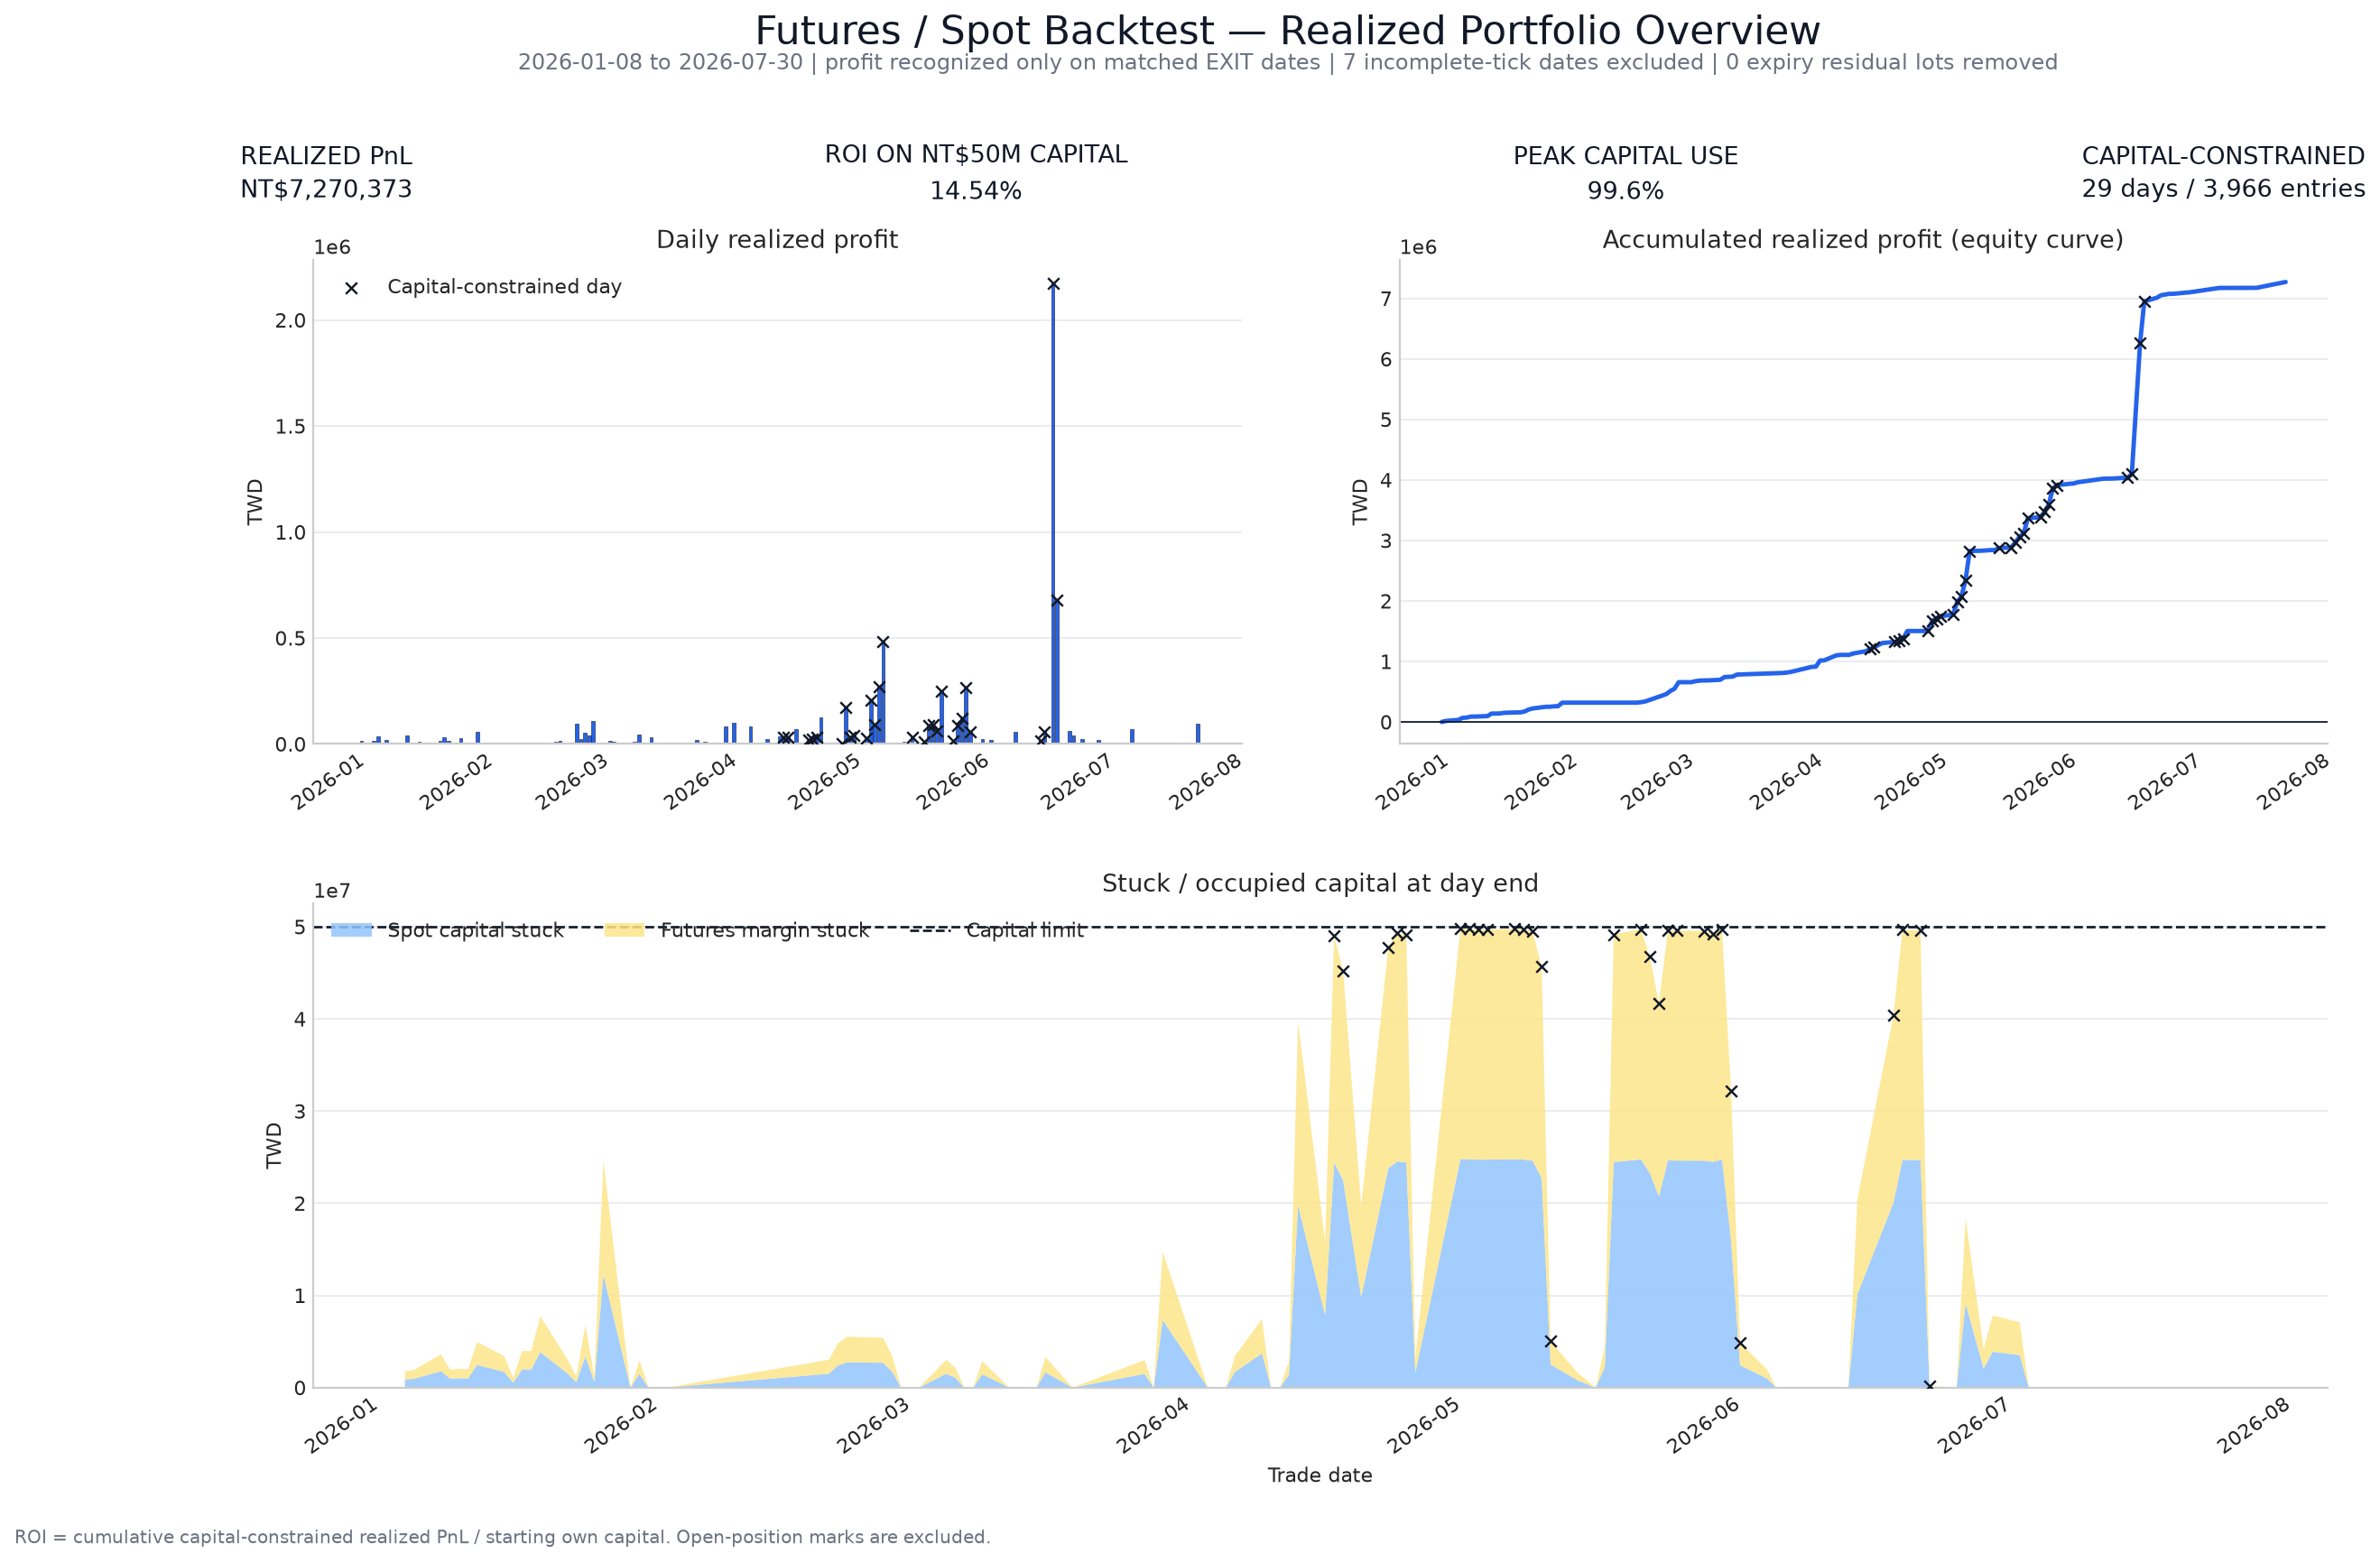

performance_overview: /home/zoufuc/hftbacktest/future_spot/output/hbt_daily_full_market_20260101_20260731_slim_compact_acc/figures/performance_overview.png


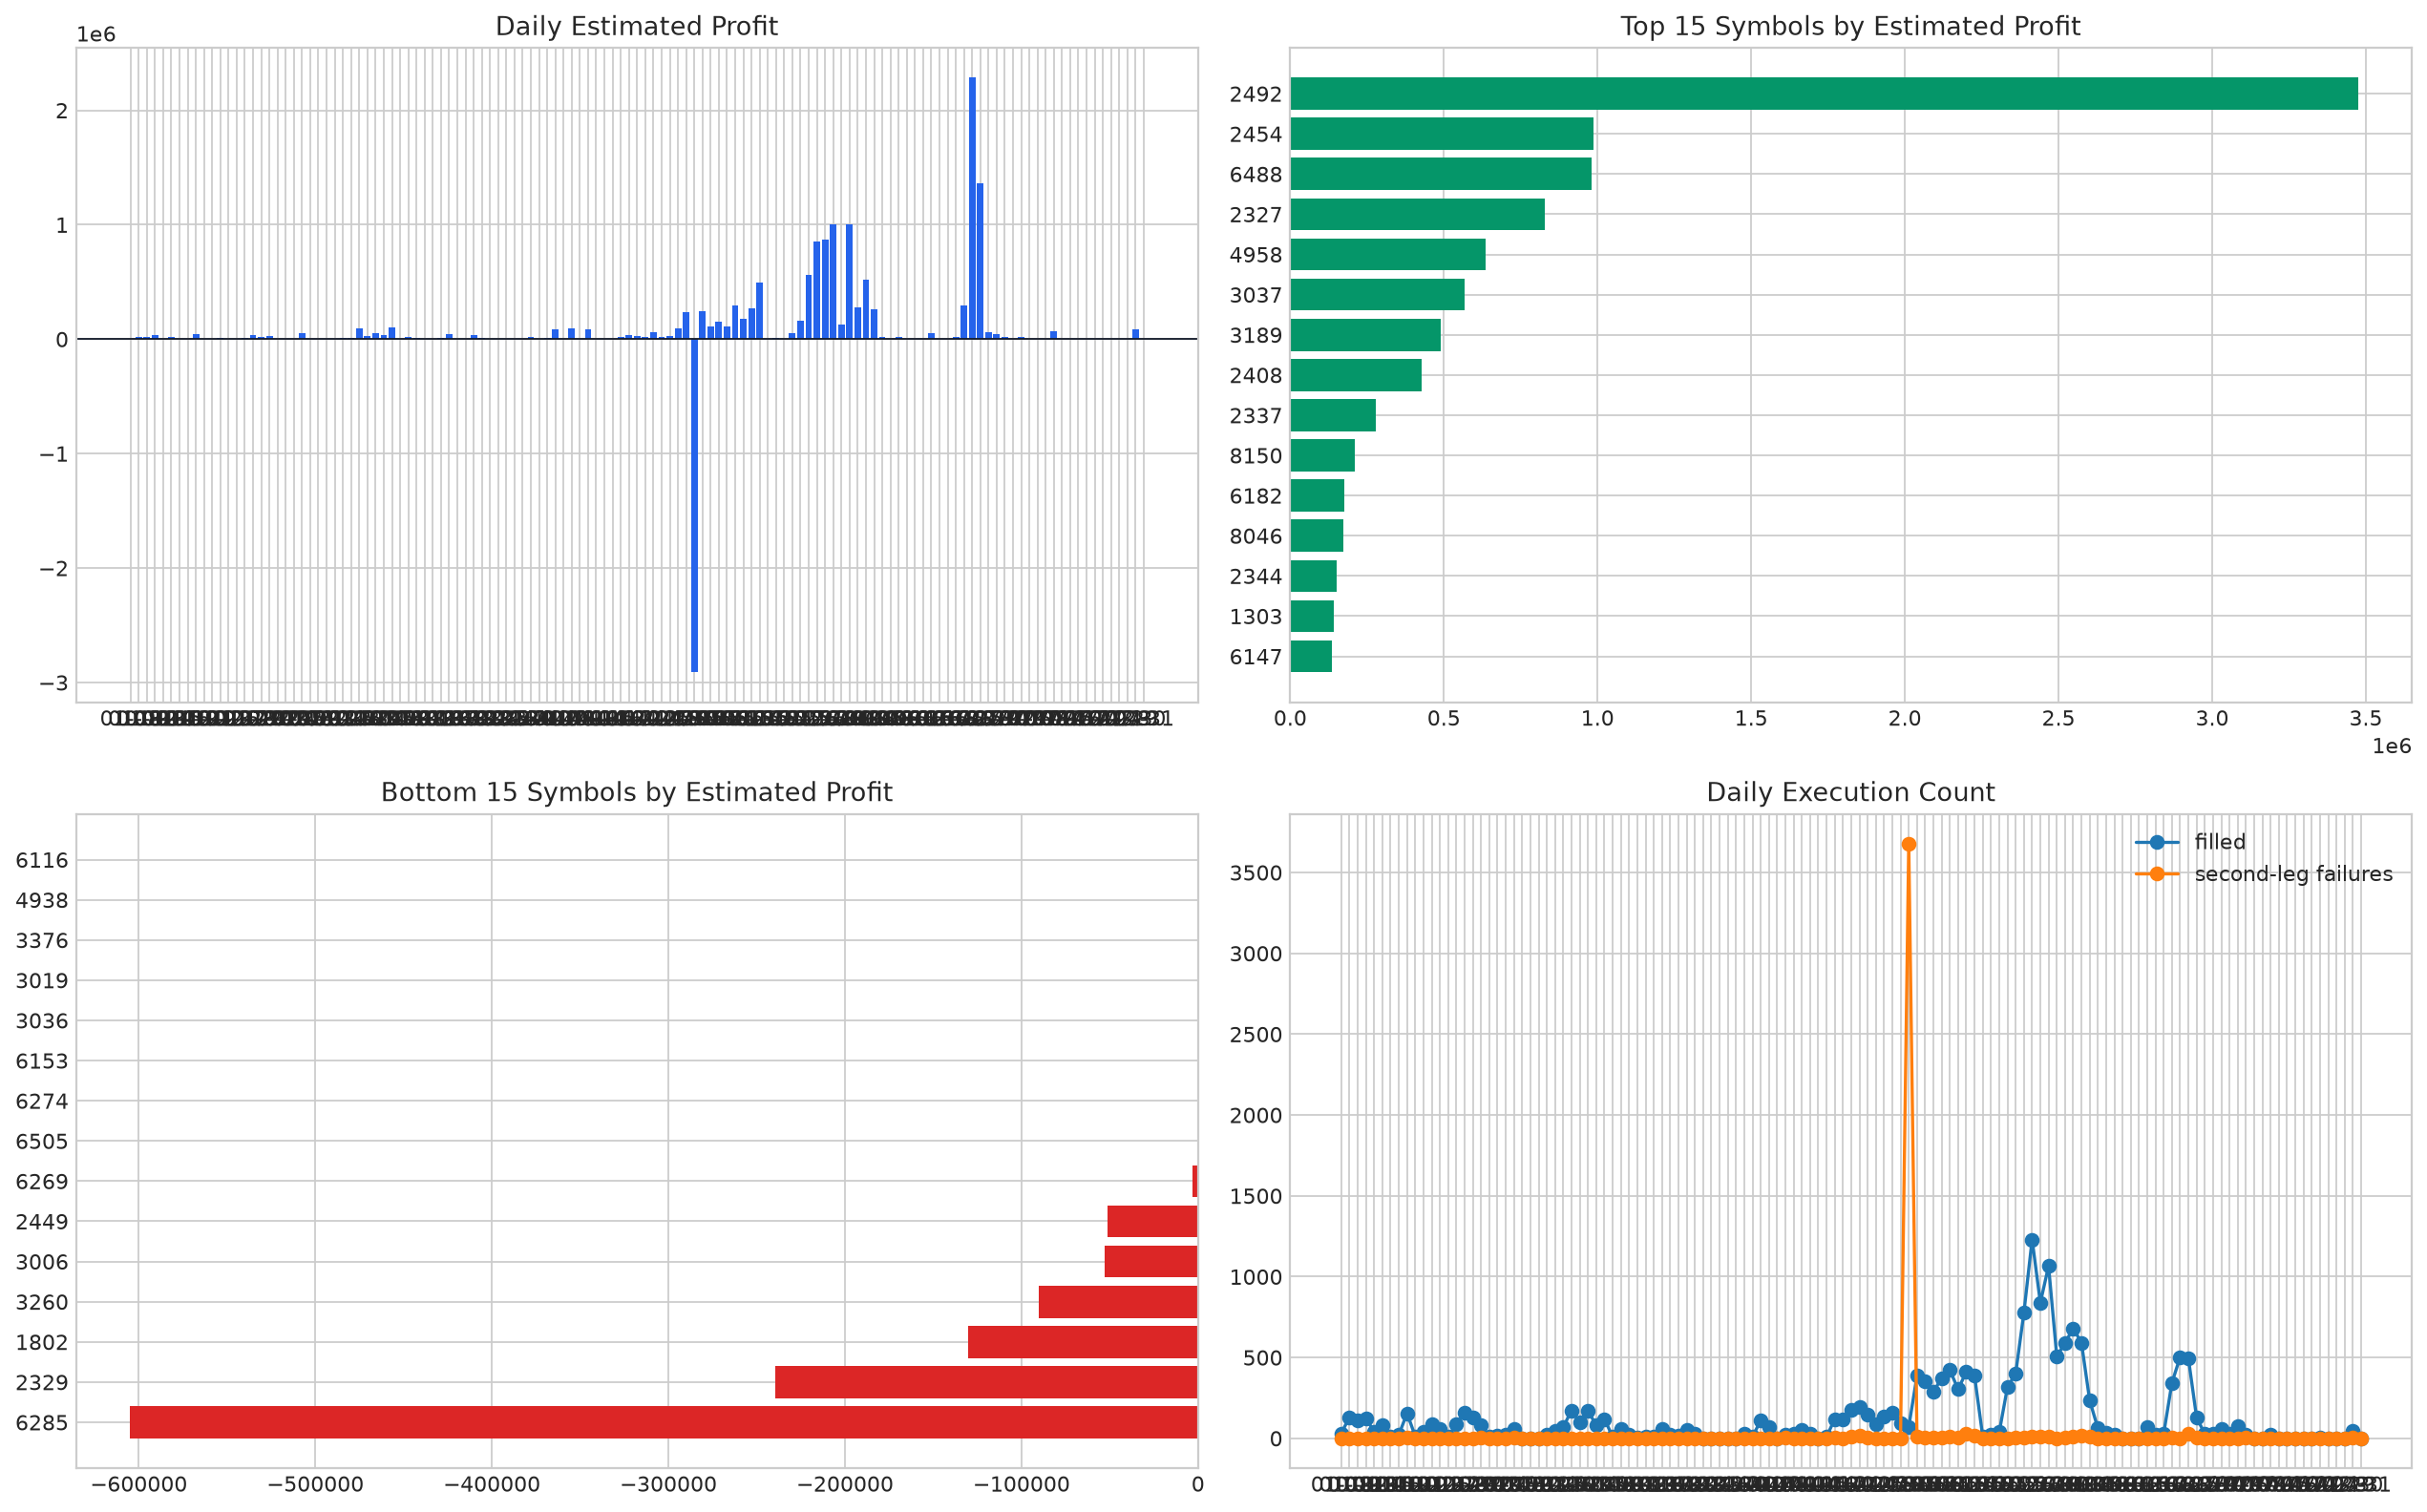

pair_profit_scatter: /home/zoufuc/hftbacktest/future_spot/output/hbt_daily_full_market_20260101_20260731_slim_compact_acc/figures/pair_profit_scatter.png


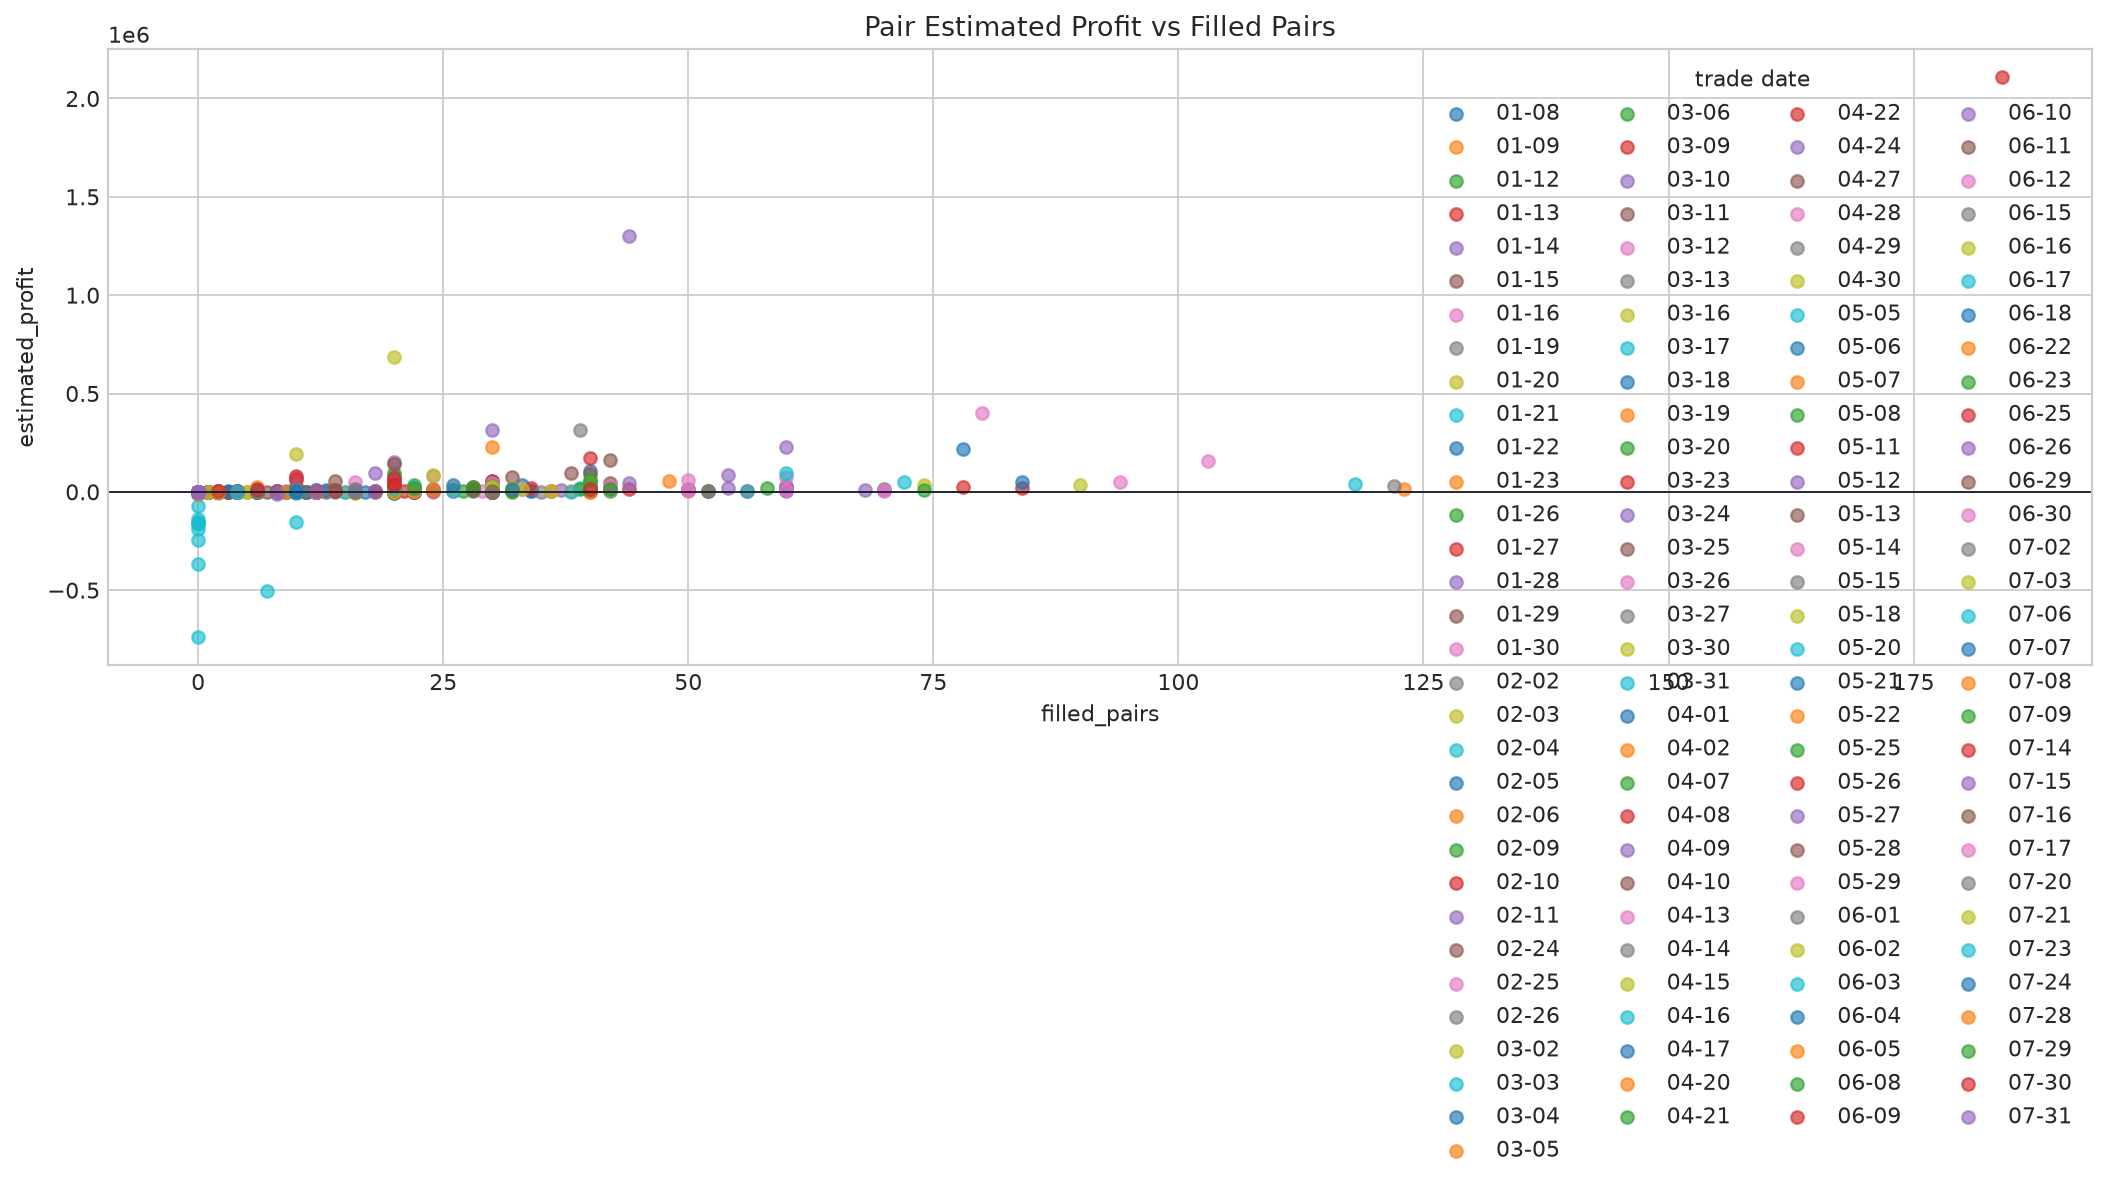

stuck_cash: /home/zoufuc/hftbacktest/future_spot/output/hbt_daily_full_market_20260101_20260731_slim_compact_acc/figures/stuck_cash.png


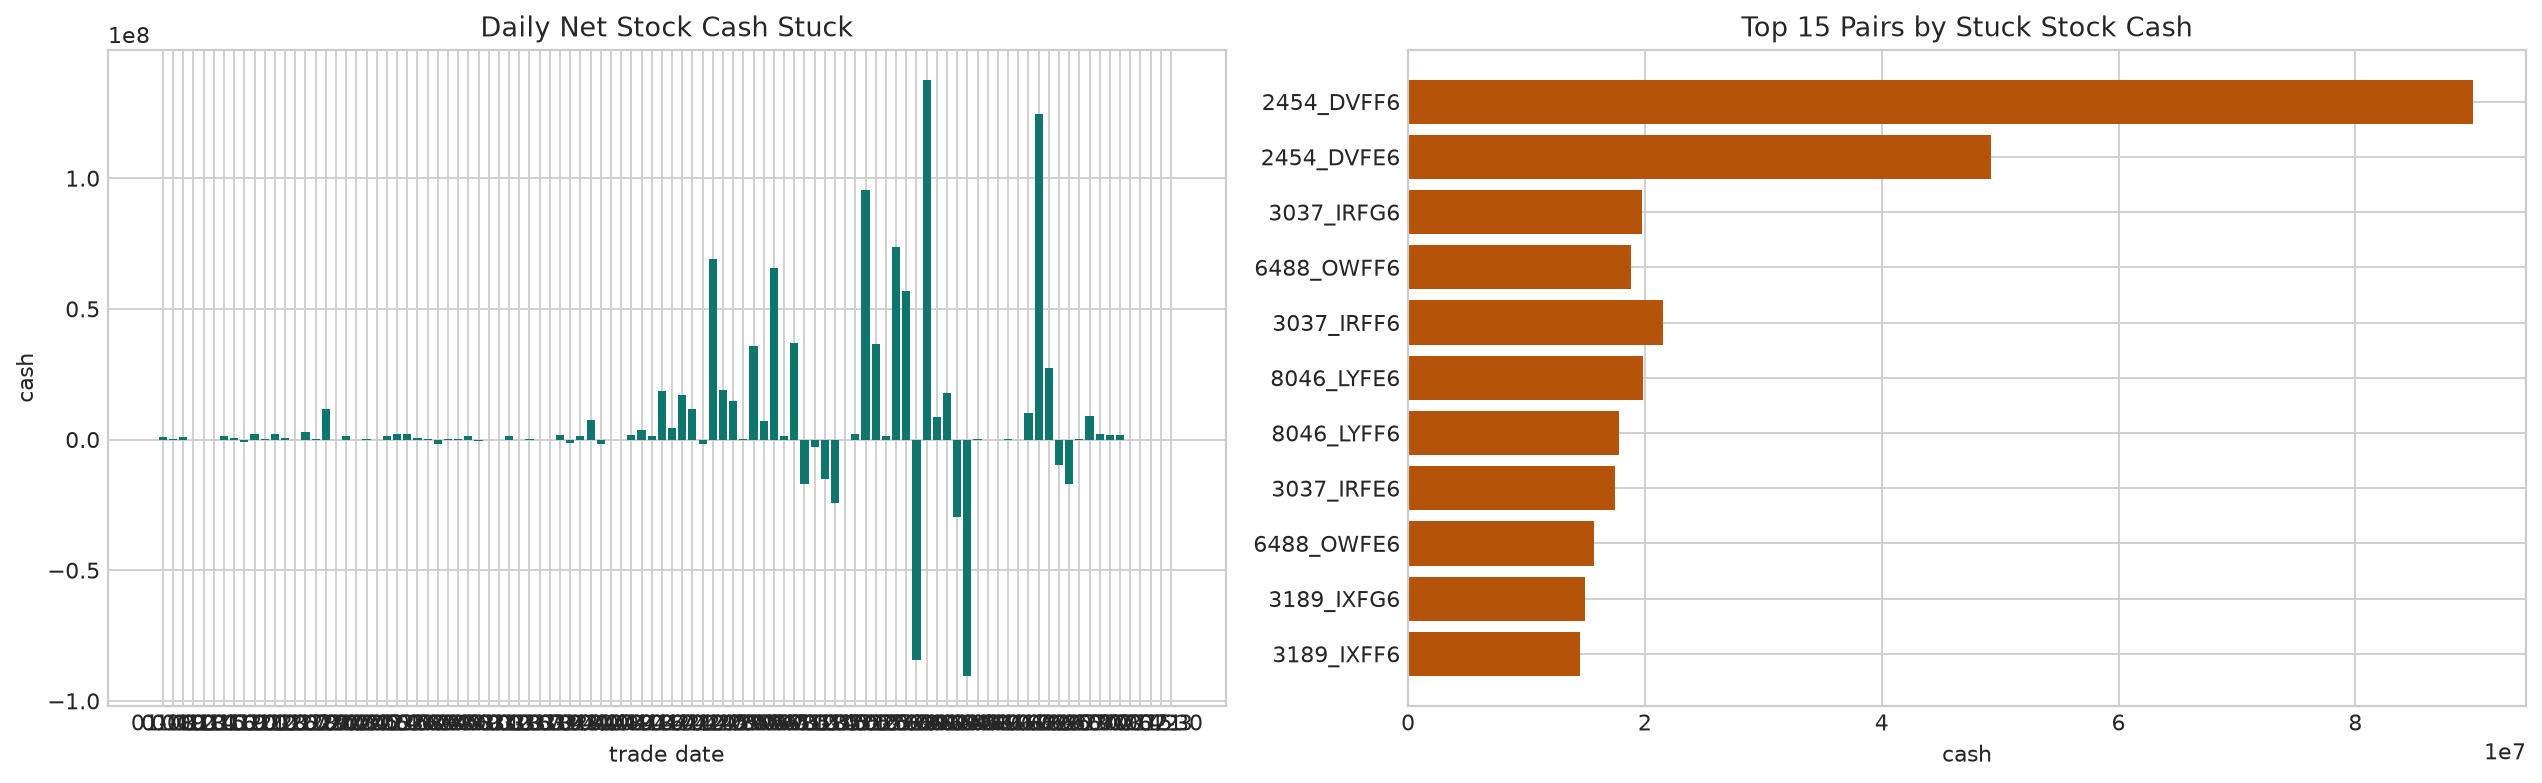

latency_timelines: /home/zoufuc/hftbacktest/future_spot/output/hbt_daily_full_market_20260101_20260731_slim_compact_acc/figures/latency_timelines.png


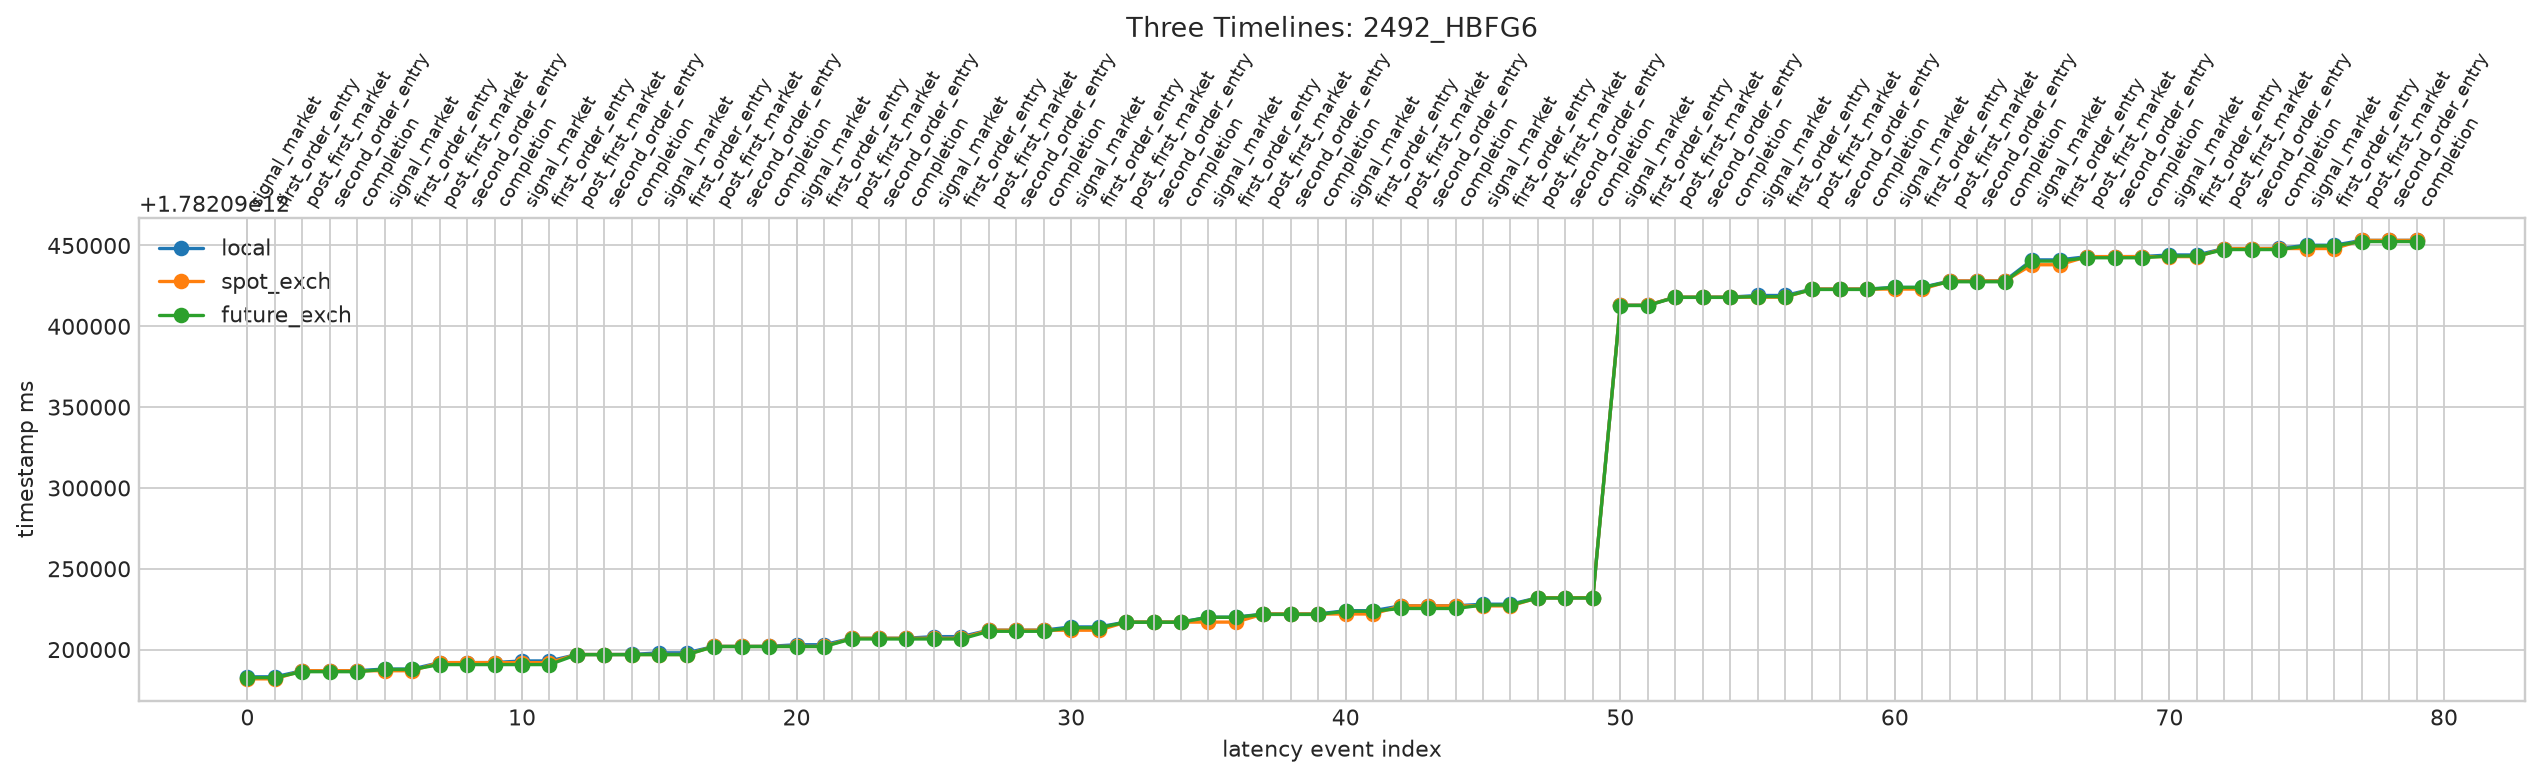

In [ ]:
figure_paths = save_report_plots(artifacts, reports, excluded_dates=PLOT_EXCLUDED_DATES)
print(f'Plot excluded dates: {", ".join(PLOT_EXCLUDED_DATES)}')
print(f'Plot exclusion audit: {artifacts.output_dir / "figures" / "plot_exclusions.csv"}')
for name, path in figure_paths.items():
    print(f'{name}: {path}')
    display(Image(filename=str(path)))

## Checks

### 5. 選擇性逐 pair 檢查

逐 pair 明細以 chunks 掃描 compatibility CSV，只保留選定 pair 的前幾筆，不重新載入整年度資料。

In [ ]:
def selected_pair_rows(csv_path, pair_name, limit, chunk_rows=25_000):
    if pair_name is None or not csv_path.exists() or csv_path.stat().st_size == 0:
        return pd.DataFrame()
    selected = []
    try:
        chunks = pd.read_csv(csv_path, chunksize=chunk_rows, low_memory=False)
        for chunk in chunks:
            if 'pair_name' not in chunk.columns:
                return pd.DataFrame()
            rows = chunk.loc[chunk['pair_name'].astype(str).eq(str(pair_name))]
            if not rows.empty:
                selected.append(rows.head(limit - sum(len(frame) for frame in selected)))
            if sum(len(frame) for frame in selected) >= limit:
                break
    except pd.errors.EmptyDataError:
        return pd.DataFrame()
    return pd.concat(selected, ignore_index=True, sort=False) if selected else pd.DataFrame()


selected_pair = reports.selected_pair
if selected_pair is None:
    print('No pair is available for drill-down.')
else:
    print(f'Selected pair: {selected_pair}')
    entry_exit_rows = selected_pair_rows(
        artifacts.output_dir / 'entry_exit_all_daily_pairs.csv', selected_pair, 100
    )
    latency_rows = selected_pair_rows(
        artifacts.output_dir / 'latency_all_daily_pairs.csv', selected_pair, 120
    )
    display(entry_exit_rows)
    display(latency_rows)

Selected pair: 2492_HBFG6


,trade_date,run_key,time,pair_name,spot_symbol,future_symbol,entry_signal,spot_bid,spot_ask,spot_ask_size,...,first_side,first_requested_price,first_exec_price,first_exec_qty,second_leg,second_side,second_requested_price,second_exec_price,second_exec_qty,first_to_second_exch_ms
0,2026-06-22,2026-06-22::2492_HBFG6,2026-06-22 09:03:03.153000+08:00,2492_HBFG6,2492,HBFG6,ENTER_LONG_SPOT_SHORT_FUTURE,579.0,580.0,68.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-06-22,2026-06-22::2492_HBFG6,2026-06-22 09:03:06.951000+08:00,2492_HBFG6,2492,HBFG6,ENTER_LONG_SPOT_SHORT_FUTURE,579.0,580.0,NaN,...,sell,587.0,587.0,1.0,stock,buy,582.0,580.0,2.0,3762.000128
2,2026-06-22,2026-06-22::2492_HBFG6,2026-06-22 09:03:07.951000+08:00,2492_HBFG6,2492,HBFG6,ENTER_LONG_SPOT_SHORT_FUTURE,579.0,580.0,69.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2026-06-22,2026-06-22::2492_HBFG6,2026-06-22 09:03:11.969000+08:00,2492_HBFG6,2492,HBFG6,ENTER_LONG_SPOT_SHORT_FUTURE,579.0,580.0,NaN,...,sell,589.0,589.0,1.0,stock,buy,582.0,580.0,2.0,3982.000128
4,2026-06-22,2026-06-22::2492_HBFG6,2026-06-22 09:03:12.969000+08:00,2492_HBFG6,2492,HBFG6,ENTER_LONG_SPOT_SHORT_FUTURE,579.0,580.0,74.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,2026-06-22,2026-06-22::2492_HBFG6,2026-06-22 09:04:37.083000+08:00,2492_HBFG6,2492,HBFG6,ENTER_LONG_SPOT_SHORT_FUTURE,579.0,580.0,23.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
96,2026-06-22,2026-06-22::2492_HBFG6,2026-06-22 09:04:38.083000+08:00,2492_HBFG6,2492,HBFG6,ENTER_LONG_SPOT_SHORT_FUTURE,579.0,580.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
97,2026-06-22,2026-06-22::2492_HBFG6,2026-06-22 09:04:38.083000+08:00,2492_HBFG6,2492,HBFG6,ENTER_LONG_SPOT_SHORT_FUTURE,579.0,580.0,35.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
98,2026-06-22,2026-06-22::2492_HBFG6,2026-06-22 09:04:39.083000+08:00,2492_HBFG6,2492,HBFG6,ENTER_LONG_SPOT_SHORT_FUTURE,579.0,580.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,trade_date,run_key,timestamp,step,pair_name,spot_symbol,future_symbol,signal,status,failure_reason,...,spot_feed_latency_ns,future_exch_ts,future_feed_local_ts,future_feed_latency_ns,order_req_local_ts,order_exch_ts,order_resp_local_ts,order_entry_latency_ns,order_response_latency_ns,time
0,2026-06-22,2026-06-22::2492_HBFG6,1782090183153000000,183,2492_HBFG6,2492,HBFG6,ENTER_LONG_SPOT_SHORT_FUTURE,SIGNAL,NaN,...,0,1782090182654000000,1782090182654000000,0,NaN,NaN,NaN,NaN,NaN,2026-06-22 09:03:03.153000+08:00
1,2026-06-22,2026-06-22::2492_HBFG6,1782090183155000000,183,2492_HBFG6,2492,HBFG6,ENTER_LONG_SPOT_SHORT_FUTURE,FIRST_ORDER_RESPONSE,NaN,...,0,1782090182654000000,1782090182654000000,0,1.782090e+18,1.782090e+18,1.782090e+18,1000000.0,1000000.0,2026-06-22 09:03:03.153000+08:00
2,2026-06-22,2026-06-22::2492_HBFG6,1782090186915000000,183,2492_HBFG6,2492,HBFG6,ENTER_LONG_SPOT_SHORT_FUTURE,POST_FIRST_MARKET,NaN,...,0,1782090186326000000,1782090186326000000,0,NaN,NaN,NaN,NaN,NaN,2026-06-22 09:03:06.915000+08:00
3,2026-06-22,2026-06-22::2492_HBFG6,1782090186951000000,183,2492_HBFG6,2492,HBFG6,ENTER_LONG_SPOT_SHORT_FUTURE,SECOND_ORDER_RESPONSE,NaN,...,0,1782090186326000000,1782090186326000000,0,1.782090e+18,1.782090e+18,1.782090e+18,1000000.0,35000000.0,2026-06-22 09:03:06.915000+08:00
4,2026-06-22,2026-06-22::2492_HBFG6,1782090186951000000,183,2492_HBFG6,2492,HBFG6,ENTER_LONG_SPOT_SHORT_FUTURE,FILLED,NaN,...,0,1782090186326000000,1782090186326000000,0,NaN,NaN,NaN,NaN,NaN,2026-06-22 09:03:06.951000+08:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,2026-06-23,2026-06-23::2492_HBFG6,1782176493051000000,64,2492_HBFG6,2492,HBFG6,EXIT,SIGNAL,NaN,...,0,1782176493028000000,1782176493028000000,0,NaN,NaN,NaN,NaN,NaN,2026-06-23 09:01:33.051000+08:00
116,2026-06-23,2026-06-23::2492_HBFG6,1782176493053000000,64,2492_HBFG6,2492,HBFG6,EXIT,FIRST_ORDER_RESPONSE,NaN,...,0,1782176493028000000,1782176493028000000,0,1.782176e+18,1.782176e+18,1.782176e+18,1000000.0,1000000.0,2026-06-23 09:01:33.051000+08:00
117,2026-06-23,2026-06-23::2492_HBFG6,1782176497033000000,64,2492_HBFG6,2492,HBFG6,EXIT,POST_FIRST_MARKET,NaN,...,0,1782176496373000000,1782176496373000000,0,NaN,NaN,NaN,NaN,NaN,2026-06-23 09:01:37.033000+08:00
118,2026-06-23,2026-06-23::2492_HBFG6,1782176497069000000,64,2492_HBFG6,2492,HBFG6,EXIT,SECOND_ORDER_RESPONSE,NaN,...,0,1782176496373000000,1782176496373000000,0,1.782176e+18,1.782176e+18,1.782176e+18,1000000.0,35000000.0,2026-06-23 09:01:37.033000+08:00


## Next Steps

預設路徑已是 `Slim + compact`。首次執行是 cold compact build，之後相同資料與參數會 zero-scan reuse 並從已驗證的連續日期續跑。需要 regression canary 時，把 `engine='reference'` 保留 `market_data_cache='compact'`，Reference 會由 compact adapter 重建 HBT 輸入；不要與 slim 共用同一個 `output_dir`。